# 01 · Pulse gates, spectroscopy and Rabi oscillations

Where the shop opened for business (May 2022) and what every later experiment starts with.

A transmon on the IBM cloud is normally driven through gates (`x`, `sx`, `rz`) whose pulses IBM calibrates.
To reach the third level $|2\rangle$ we have to play our own pulses. With Qiskit Pulse this is a *pulse gate*:
a `Gate` placeholder in a circuit plus a schedule attached with `add_calibration`. Everything in this repository
is built that way, on `ibmq_manila`, `ibmq_belem`, `ibm_oslo` (2022), `ibm_lagos` (2023) and `ibm_brisbane` (2023–25).

This notebook

1. shows how a pulse gate and the three standard calibration experiments (frequency sweep, Rabi, 1–2 spectroscopy) are written;
2. re-analyses the saved 2024 spectroscopy / Rabi data of `ibm_brisbane` qubit 1 and the 2025 Rabi data of qubit 109 with `pulseshop`;
3. records how the $\pi$ amplitude of the 1–2 pulse scales with pulse duration (the 2024 "duration mapping").

Hardware cells are guarded by `backend = None`; set a real backend (with `qiskit<2`) to run them.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # so that `pulseshop` imports without installing
import numpy as np
import matplotlib.pyplot as plt
import json
import pulseshop as pps
from pulseshop import constants as C, fitting, io

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
backend = None   # e.g. QiskitRuntimeService().backend('ibm_brisbane')

## 1. Anatomy of a pulse gate

The 2022 notebooks (`pulse-gate.ipynb`, "The emergence of Pulse Gate") taught us the pattern below. The
frequency, duration (in units of `dt = 0.5 ns`, multiples of 16) and amplitude (fraction of the maximum drive)
are the three numbers every calibration produces; `pulseshop.constants.PARAMS` keeps the history of those numbers.

In [2]:
from pulseshop import schedules
print("qiskit.pulse available:", schedules.HAVE_PULSE)

if backend is not None:
    from qiskit.circuit import QuantumCircuit
    qubit = 109
    p = C.PARAMS["brisbane_q109_2025-02"]
    x12_sched = schedules.rotation_schedule(backend, qubit, p["f12"], p["x12"]["duration"], p["x12"]["amp"], beta=p["x12"]["beta"])
    x12 = schedules.gate("x12")
    qc = QuantumCircuit(qubit + 1, 1)
    qc.x(qubit)                       # IBM's calibrated 0-1 pi pulse
    qc.append(x12, [qubit])           # our 1-2 pi pulse
    qc.add_calibration(x12, [qubit], x12_sched)
    qc.measure(qubit, 0)
    qc.draw("mpl")

qiskit.pulse available: True


Durations must respect the hardware granularity. The helpers below (textbook `get_closest_multiple_of_16`) are in `pulseshop.constants`:

In [3]:
print(C.get_closest_multiple_of_16(150), C.get_dt_from(80e-9), "samples;  dt =", C.dt, "s")

144 160 samples;  dt = 5e-10 s


## 2. Which pulse parameters were used when

The pulses we calibrated over three years, from `xp01.py` / `xp12.py` (2022), `pulse.py` (2023) and the json parameter files (2025).

In [4]:
for key, val in C.PARAMS.items():
    pulses = {k: v for k, v in val.items() if isinstance(v, dict) and "amp" in v and "duration" in v}
    print(f"{key:24s} {val['device']:13s} q{val['qubit']:<4d}", "  ".join(f"{k}: dur {v['duration']} amp {v['amp']:.4f}" + (f" beta {v['beta']}" if v.get('beta') is not None else "") for k, v in pulses.items()))

manila_q0_2022-05        ibmq_manila   q0    
manila_q0_2022-09        ibmq_manila   q0    x01: dur 544 amp 0.0928  x01_fast: dur 160 amp 0.2128  x12: dur 160 amp 0.1731
manila_q0_2022-10        ibmq_manila   q0    x01: dur 320 amp 0.1022  x12: dur 320 amp 0.0822
oslo_q0_2022-08          ibm_oslo      q0    x01: dur 544 amp 0.0800  x12: dur 544 amp 0.1088
oslo_q0_2022-10          ibm_oslo      q0    x01: dur 320 amp 0.0751  x12: dur 320 amp 0.0708
oslo_q0_2022-11          ibm_oslo      q0    x01: dur 320 amp 0.0877 beta -0.17  x12: dur 320 amp 0.0687 beta 0.5
lagos_q0_2023-08         ibm_lagos     q0    x01: dur 160 amp 0.4151 beta -1.1  x12: dur 144 amp 0.3291
brisbane_q0_2023-12      ibm_brisbane  q0    x12: dur 160 amp 0.2403 beta 2.0
brisbane_q109_2023-12    ibm_brisbane  q109  x12: dur 96 amp 0.2235 beta -0.5
brisbane_q109_2024-02    ibm_brisbane  q109  r01: dur 120 amp 0.1809 beta -1.2643134385128565  r12: dur 64 amp 0.3142 beta -0.7678179824177247
brisbane_q109_2024-05    ibm_br

Two trends are visible: the pulses got shorter (544 → 320 → 160 → 96 → 64 → 40 samples) and, since a shorter Gaussian
needs a larger area per unit time, the $\pi$ amplitudes grew. The 20 ns (40 dt) pulse of the 2025 paper is close to the
shortest the IBM drive line allows at full amplitude.

## 3. Spectroscopy and Rabi on `ibm_brisbane` qubit 1 (May 2024)

`characterization/spectroscopy01`, `spectroscopy12`, `rabi01` and `ramseyv0_01` were the first systematic characterisation
done with `utility.DataAnalysis`. The saved files are the averaged (meas_level 1) resonator signal.
Frequencies are swept ±25 MHz around the backend estimate in 1 MHz steps (0–1), ±50 MHz in 2 MHz steps (1–2, rounds 1–2).

0-1 spectroscopy (32 dt, amp 0.3): f01 = 4.81368 GHz, FWHM ~ 130.8 MHz
0-1 spectroscopy (120 dt, amp 0.1): f01 = 4.81554 GHz, FWHM ~ 27.5 MHz


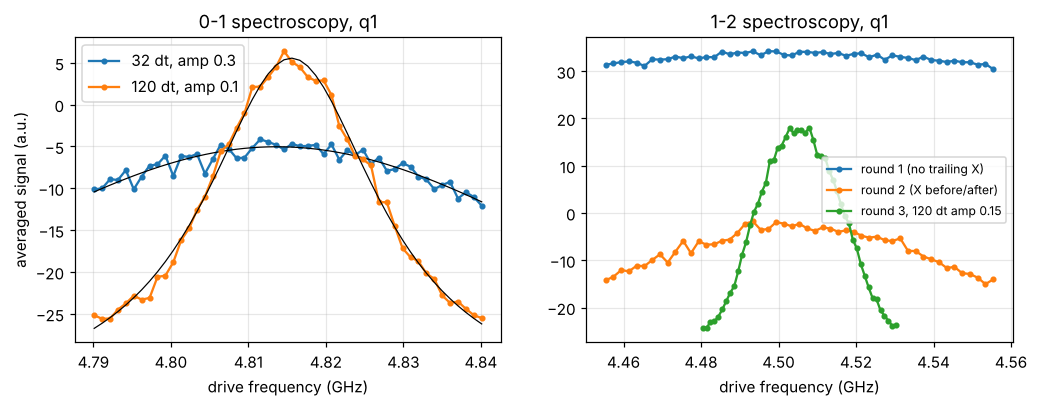

In [5]:
spec01 = [io.load_npy("shop_2024/characterization/spectroscopy01/data", f"round{i}.npy") for i in (1, 2)]
spec12 = [io.load_npy("shop_2024/characterization/spectroscopy12/data", f"round{i}.npy") for i in (1, 2, 3)]
f_q1_01 = 4.8151   # GHz, backend estimate printed in the notebook
f_q1_12 = 4.5054

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for sig, lab in zip(spec01, ["32 dt, amp 0.3", "120 dt, amp 0.1"]):
    df = np.linspace(-25, 25, len(sig))
    axes[0].plot(f_q1_01 + df / 1e3, sig, ".-", label=lab)
    best = None
    for sign in (+1, -1):      # the line can be a peak or a dip depending on the readout phase
        try:
            pars, yfit, _ = fitting.fit_function(df, sig, fitting.lorentzian, [sign * (sig.max() - sig.min()) * 5, df[np.argmax(sign * (sig - np.median(sig)))], 3, np.median(sig)])
            err = np.sum((yfit - sig) ** 2)
            if best is None or err < best[0]:
                best = (err, pars, yfit)
        except RuntimeError:
            pass
    if best is not None:
        _, pars, yfit = best
        axes[0].plot(f_q1_01 + df / 1e3, yfit, "k-", lw=0.8)
        print(f"0-1 spectroscopy ({lab}): f01 = {f_q1_01 + pars[1]/1e3:.5f} GHz, FWHM ~ {2*abs(pars[2]):.1f} MHz")
axes[0].set(xlabel="drive frequency (GHz)", ylabel="averaged signal (a.u.)", title="0-1 spectroscopy, q1")
axes[0].legend()
for sig, lab, span in zip(spec12, ["round 1 (no trailing X)", "round 2 (X before/after)", "round 3, 120 dt amp 0.15"], [50, 50, 25]):
    df = np.linspace(-span, span, len(sig))
    axes[1].plot(f_q1_12 + df / 1e3, sig, ".-", label=lab)
axes[1].set(xlabel="drive frequency (GHz)", title="1-2 spectroscopy, q1")
axes[1].legend(fontsize=8)
io.save_fig(fig, "01_spectroscopy_q1_2024")

The 1–2 line is found at $f_{01} + \alpha$ with $\alpha \approx -310$ MHz, the anharmonicity. Round 2 brackets the probe with
an X pulse on each side so that a successful 1→2 transfer shows up as *reduced* |1⟩ signal — the trick we reuse everywhere.

Rabi oscillations: the Gaussian amplitude is swept from −0.75 to 0.75; the half period of the cosine is the $\pi$ amplitude.

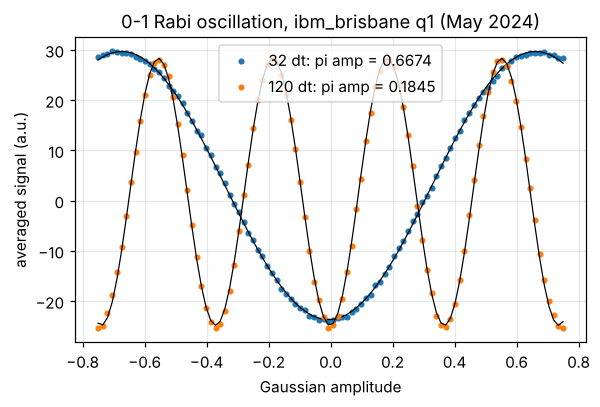

In [6]:
rabi01 = [io.load_npy("shop_2024/characterization/rabi01/data", f"round{i}.npy") for i in (1, 2)]
amps = np.linspace(-0.75, 0.75, 100)
fig, ax = plt.subplots(figsize=(6, 3.6))
for sig, lab in zip(rabi01, ["32 dt", "120 dt"]):
    pi_amp, pars, yfit = fitting.pi_amplitude_from_cosine_fit(amps, sig)
    ax.plot(amps, sig, ".", label=f"{lab}: pi amp = {pi_amp:.4f}")
    ax.plot(amps, yfit, "k-", lw=0.8)
ax.set(xlabel="Gaussian amplitude", ylabel="averaged signal (a.u.)", title="0-1 Rabi oscillation, ibm_brisbane q1 (May 2024)")
ax.legend()
io.save_fig(fig, "01_rabi01_q1_2024")

The notebook of the time recorded 0.66743 for the 32 dt pulse (the number used as `amp_sx01 = 0.66743/2` in the Ramsey of the same week).

## 4. The 1–2 Rabi oscillation that defined the paper's pulse (qubit 109, Jan 2025)

`characterization/rabi/rabi_script.ipynb` plays X, then **two** identical 1–2 pulses of 40 dt, then X, and sweeps the amplitude with
10 000 single shots per point. Two pulses are used so that the first maximum of $P_2$ sits at the $\pi/2$ amplitude directly.
The single-shot clouds at the extremes of the oscillation also give the |0⟩ and |2⟩ cluster centres used by the paper's discriminator (notebook 02).

2025-01-26 duration 40 dt; (300, 10000) shots per point


recorded in sx12_params.json: {'freq': 4677857270.602841, 'dur': 40, 'amp': 0.23678929765886286, 'beta': 0}


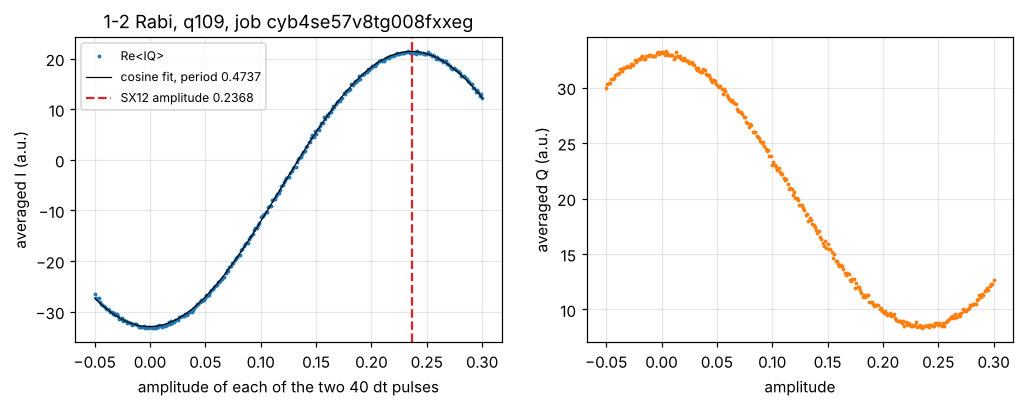

In [7]:
iq, prm = io.load_job("pending_2025/characterization/rabi/data/cyb4se57v8tg008fxxeg")
amps = np.linspace(prm["infimum"], prm["supremum"], prm["num_points"])
mean_iq = iq.mean(axis=1)
print(prm["datetime"][:10], "duration", prm["duration"], "dt;", iq.shape, "shots per point")

sig = np.real(mean_iq)
pi_half_amp, pars, yfit = fitting.pi_amplitude_from_cosine_fit(amps, sig, guess_period=0.5)
# with two pulses back to back the first maximum is at the pi/2 amplitude of one pulse
sx12_amp = abs(pars[2]) / 2
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(amps, sig, ".", ms=3, label="Re<IQ>")
axes[0].plot(amps, yfit, "k-", lw=0.8, label=f"cosine fit, period {abs(pars[2]):.4f}")
axes[0].axvline(sx12_amp, color="tab:red", ls="--", label=f"SX12 amplitude {sx12_amp:.4f}")
axes[0].set(xlabel="amplitude of each of the two 40 dt pulses", ylabel="averaged I (a.u.)", title="1-2 Rabi, q109, job cyb4se57v8tg008fxxeg")
axes[0].legend(fontsize=8)
axes[1].plot(amps, np.imag(mean_iq), ".", ms=3, color="tab:orange")
axes[1].set(xlabel="amplitude", ylabel="averaged Q (a.u.)")
io.save_fig(fig, "01_rabi12_q109_2025")
print("recorded in sx12_params.json:", json.load(open(io.data_path("pending_2025/sx12_params.json"))))

The fit reproduces the value stored in `sx12_params.json` (0.23679): one 20 ns Gaussian of that amplitude is the $\sqrt{X}$ of the 1–2 subspace, two of them the $\pi$ pulse (0.4798 in `x12_params.json`).

## 5. Pulse duration versus $\pi$ amplitude (the 2024 "duration mapping")

Before settling on 40 dt we measured the 1–2 Rabi oscillation for durations from 16 to 136 dt (`characterization/rabi12/qubit109`,
batches 1–3). The averaged traces of batch 1 and the fitted amplitudes are below; a Gaussian of fixed shape has an area ∝ duration × amplitude,
so the $\pi$ amplitude should scale as 1/duration until the drive saturates.

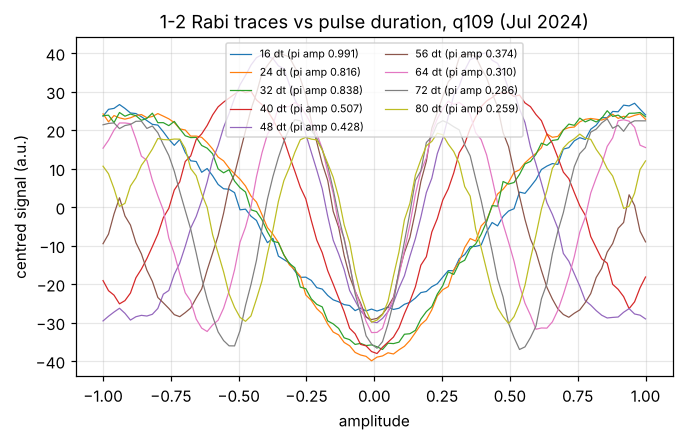

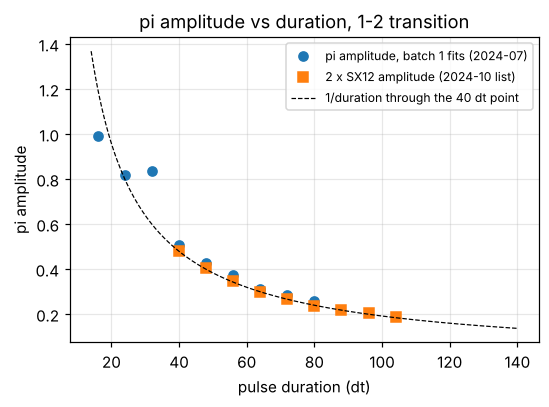

In [8]:
import glob, os
durs, pis = [], []
fig, ax = plt.subplots(figsize=(7, 4))
for f in sorted(glob.glob(str(io.data_path("shop_2024/characterization/rabi12/qubit109/data/batch1_mapping/*_average.npy")))):
    d = int(os.path.basename(f).split("_")[0])
    sig = np.load(f)
    amps = np.linspace(-1.0, 1.0, len(sig))   # batch 1 swept the full range -1..1 (cf. figures/shop_2024/..._rabi12_duration_16dt.png)
    try:
        pa, pars, yfit = fitting.pi_amplitude_from_cosine_fit(amps, sig)
        durs.append(d); pis.append(pa)
        ax.plot(amps, sig - sig.mean(), lw=0.8, label=f"{d} dt (pi amp {pa:.3f})")
    except RuntimeError:
        pass
ax.set(xlabel="amplitude", ylabel="centred signal (a.u.)", title="1-2 Rabi traces vs pulse duration, q109 (Jul 2024)")
ax.legend(fontsize=7, ncol=2)
io.save_fig(fig, "01_rabi12_duration_traces_2024")

amp_dt = io.load_npy("pending_2025/misc/amp_dt", "amp_sx12_list.npy")   # (amp_sx12, duration) pairs recorded later (Oct 2024)
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(durs, pis, "o", label="pi amplitude, batch 1 fits (2024-07)")
ax.plot(amp_dt[:, 1], 2 * amp_dt[:, 0], "s", label="2 x SX12 amplitude (2024-10 list)")
dd = np.linspace(14, 140, 200)
ax.plot(dd, 2 * amp_dt[0, 0] * amp_dt[0, 1] / dd, "k--", lw=0.8, label="1/duration through the 40 dt point")
ax.set(xlabel="pulse duration (dt)", ylabel="pi amplitude", title="pi amplitude vs duration, 1-2 transition")
ax.legend(fontsize=8)
io.save_fig(fig, "01_pi_amplitude_vs_duration")

The July 2024 fits and the October 2024 list fall on the same curve: the $\pi$ amplitude follows 1/duration from 104 dt down
to 40 dt. Below 40 dt it bends away from the law and saturates near the maximum drive (1.0 is the hardware limit; the 16 dt
pulse already needs 0.99), so 40 dt with amplitude ≈ 0.48 is the shortest clean $\pi$ pulse. That is why the 2025 paper uses
20 ns pulses.

### Where to go next
* notebook 02 — turning these IQ clouds into populations;
* notebook 03 — DRAG: the quadrature correction that a 20 ns pulse badly needs;
* notebook 09 — the Ramsey and $T_1$ measurements that complete the characterisation.